In [27]:
import keras 
from matplotlib import pyplot as plt
import pandas as pd

In [22]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [24]:
assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [25]:
X_train.shape,y_train.shape,y_test.shape

((60000, 28, 28), (60000,), (10000,))

In [33]:
pd.set_option('display.max_columns',27)
pd.DataFrame(X_train[10000])

,0,1,2,3,4,5,6,7,8,9,10,11,12,...,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,29,150,195,254,...,176,193,150,96,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,48,166,224,253,253,234,...,253,253,253,233,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,93,244,249,253,187,46,10,8,...,194,253,253,233,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,107,253,253,230,48,0,0,0,...,192,253,253,156,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,3,20,20,15,0,0,0,0,...,224,253,245,74,0,0,0,0,0,0,0,0,0


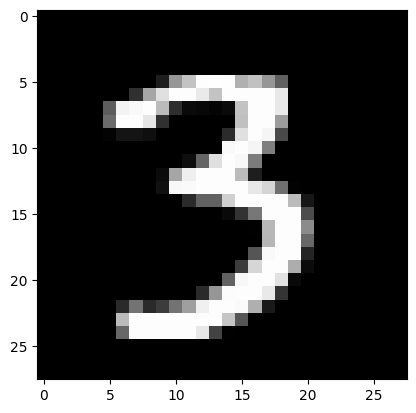

In [37]:
plt.imshow(X_train[10000],cmap='grey')

In [38]:
X_train  = X_train/255.0
X_test  = X_test/255.0

In [41]:
X_train.min() , X_train.max()

(np.float64(0.0), np.float64(1.0))

In [42]:
X_test.min() , X_test.max()

(np.float64(0.0), np.float64(1.0))

## Model Building

In [43]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [44]:
Model = Sequential()

In [45]:
Model.add(layer = Flatten())
Model.add(Dense(units = 100,activation='relu'))
Model.add(Dense(units = 10,activation='softmax'))

In [46]:
Model.compile(optimizer='rmsprop',loss="sparse_categorical_crossentropy",metrics=['sparse_categorical_crossentropy'])

### Model Training || Model Testing

In [47]:
Model.fit(x=X_train,y=y_train,batch_size=32,epochs=10,validation_data = (X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2741 - sparse_categorical_crossentropy: 0.2741 - val_loss: 0.1589 - val_sparse_categorical_crossentropy: 0.1589
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1317 - sparse_categorical_crossentropy: 0.1317 - val_loss: 0.1179 - val_sparse_categorical_crossentropy: 0.1179
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0970 - sparse_categorical_crossentropy: 0.0970 - val_loss: 0.1008 - val_sparse_categorical_crossentropy: 0.1008
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0783 - sparse_categorical_crossentropy: 0.0783 - val_loss: 0.0917 - val_sparse_categorical_crossentropy: 0.0917
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0659 - sparse_categorical_crossentropy: 0.0659 - val_loss: 0.0863 - val_sparse_categorical_crossentropy: 0.0863
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0572 - sparse_categorical_crossentropy: 0.0572 - val_los

In [49]:
Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 10)                    │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.60 KB)

In [50]:
y_pred = Model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


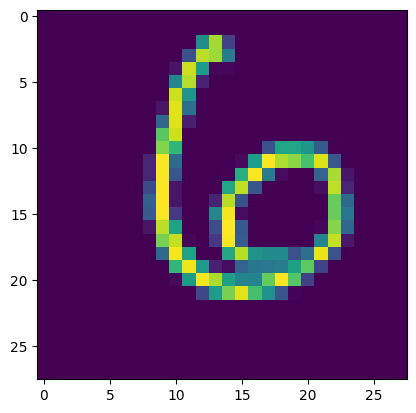

In [58]:
plt.imshow(X_test[100])

In [62]:
import numpy as np

In [63]:
np.argmax(y_pred[100])

np.int64(6)